In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

from trainer import Trainer

from models.linear_model import LinearRegressionModel
from models.ridge_model import RidgeRegressionModel
from models.lasso_model import LassoRegressionModel
from models.decision_tree_model import DecisionTreeModel
from models.random_forest_model import RandomForestModel
from models.gradient_boosting_model import GradientBoostingModel
from notebooks.visualization.visualizer import Visualizer

In [2]:
df = pd.read_csv('../Datasets/data_selection_uber.csv')
df.head()

,pickup_year,bearing,avg_distance_to_center,is_airport,manhattan_distance,fare_amount
0,2015,194084.859358,3.269602,0,1.714050,7.5
1,2009,129349.009348,2.273579,0,2.492505,7.7
2,2009,145891.484677,2.526286,0,8.253405,12.9
3,2009,141549.478955,4.528854,0,2.587743,5.3
4,2014,106291.775277,3.215304,0,7.239531,16.0


In [3]:
X = df.drop(columns=["fare_amount"])
y = df["fare_amount"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

In [5]:
models = [
    LinearRegressionModel(),
    RidgeRegressionModel(),
    LassoRegressionModel(),
    DecisionTreeModel(),
    RandomForestModel(),
    GradientBoostingModel(),
]

In [6]:
trainer = Trainer(models)

In [7]:
comparison = trainer.train_and_evaluate(
    X_train,
    X_test,
    y_train,
    y_test
)


Model Comparison
                              MAE      MSE    RMSE      R2
RandomForestRegressor      1.9304  13.4179  3.6630  0.8475
LinearRegression           2.4392  22.2629  4.7184  0.7469
Ridge                      2.4392  22.2629  4.7184  0.7469
Lasso                      2.4200  22.5832  4.7522  0.7433
DecisionTreeRegressor      2.5969  26.3291  5.1312  0.7007
GradientBoostingRegressor  3.2285  27.3823  5.2328  0.6887


In [9]:
comparison.to_csv("model_comparison.csv", index=True)

In [10]:
best_model, metrics = trainer.get_best_model()

print("\nBest Model")
print("=" * 30)
print(best_model)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


Best Model
RandomForestRegressor
MAE: 1.9304
MSE: 13.4179
RMSE: 3.6630
R2: 0.8475


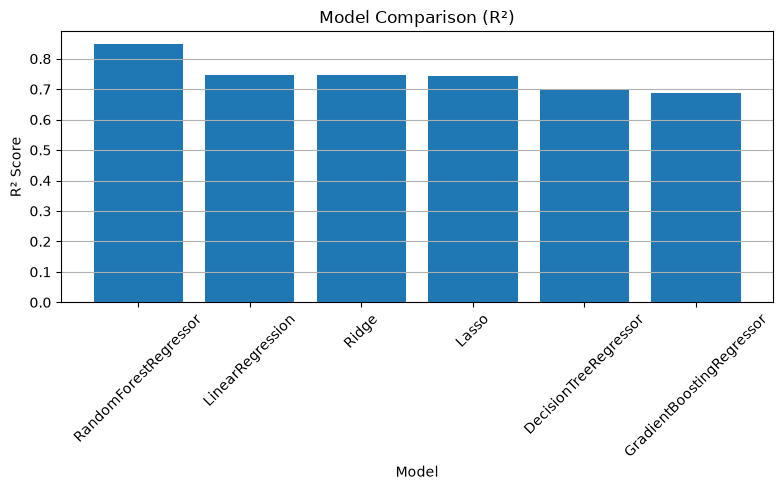

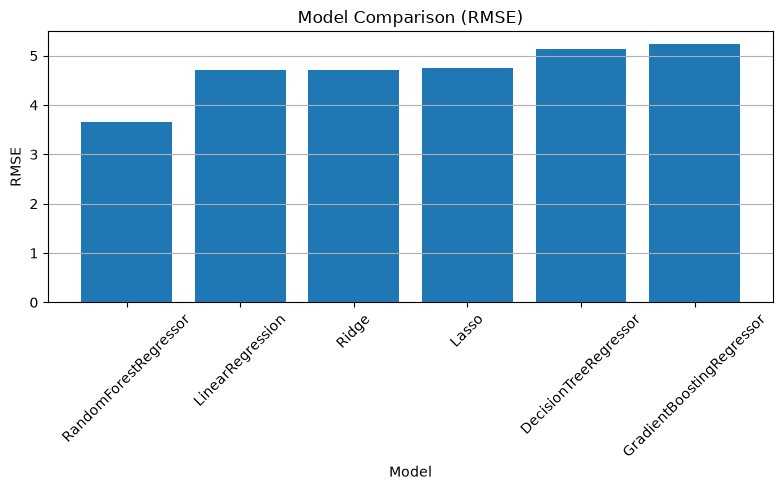

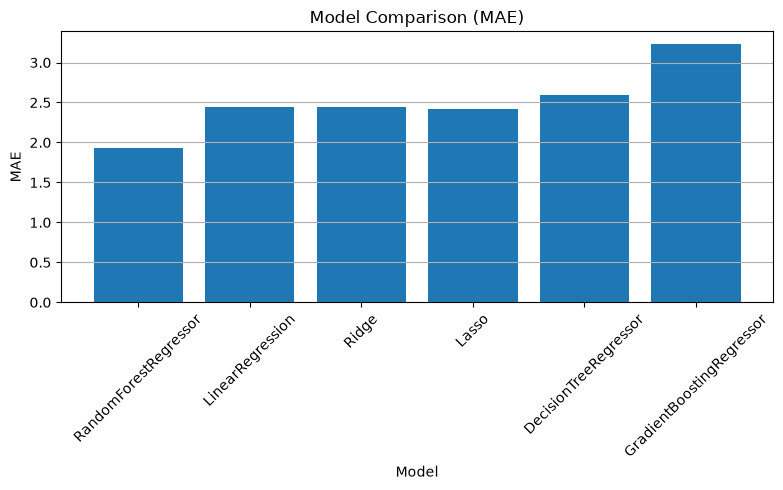

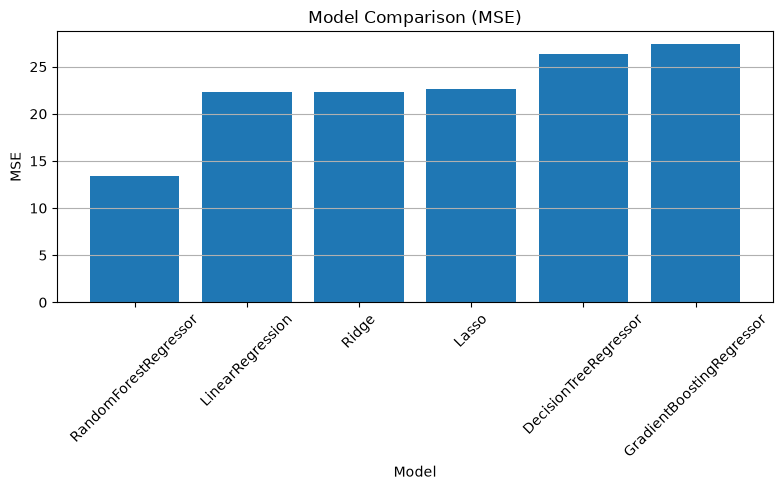

In [11]:
# Comparison Charts
Visualizer.plot_r2_scores(comparison)
Visualizer.plot_rmse(comparison)
Visualizer.plot_mae(comparison)
Visualizer.plot_mse(comparison)

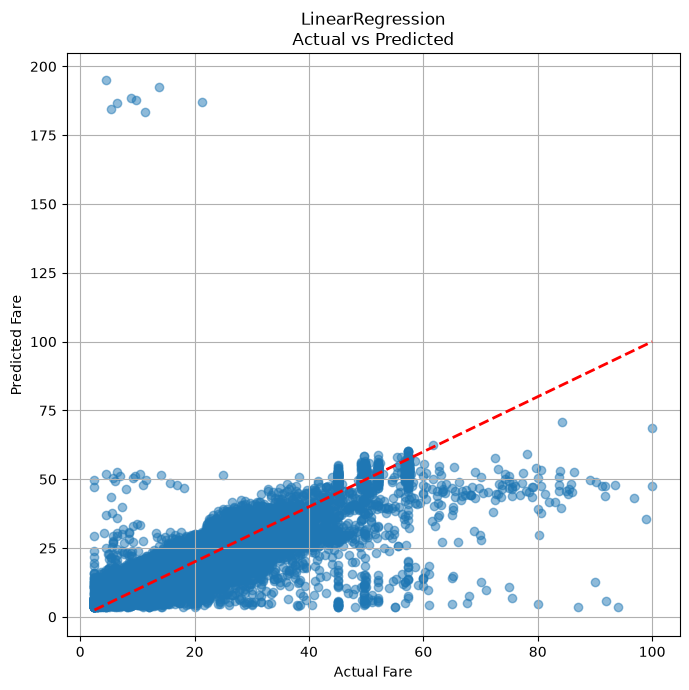

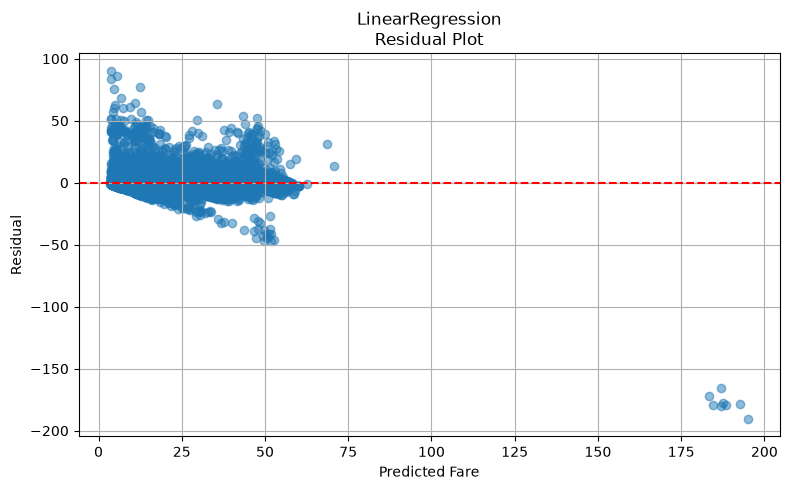

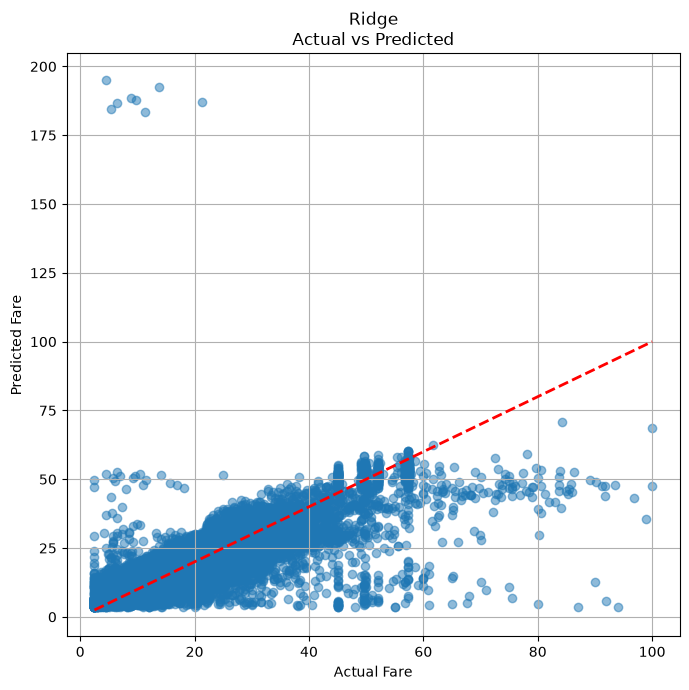

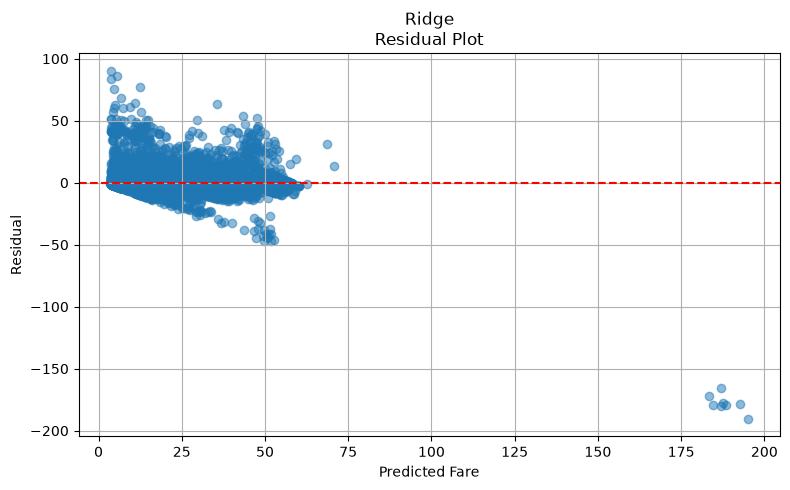

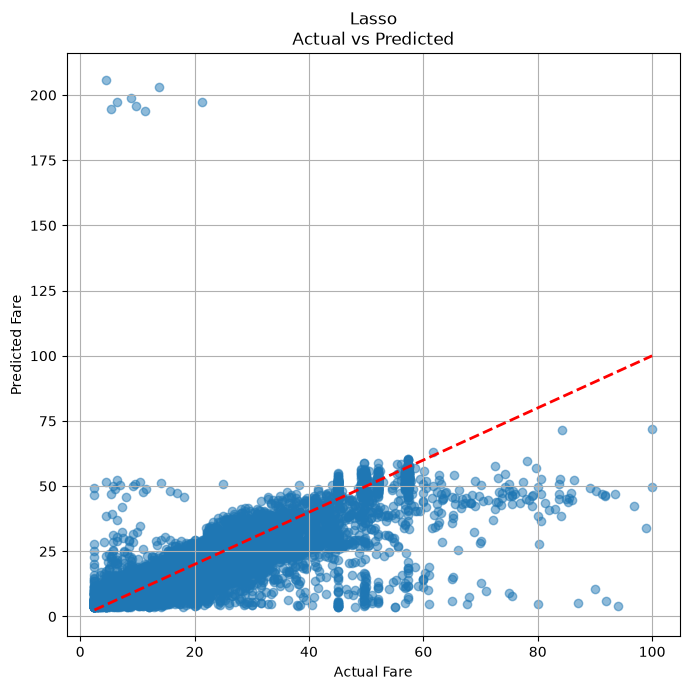

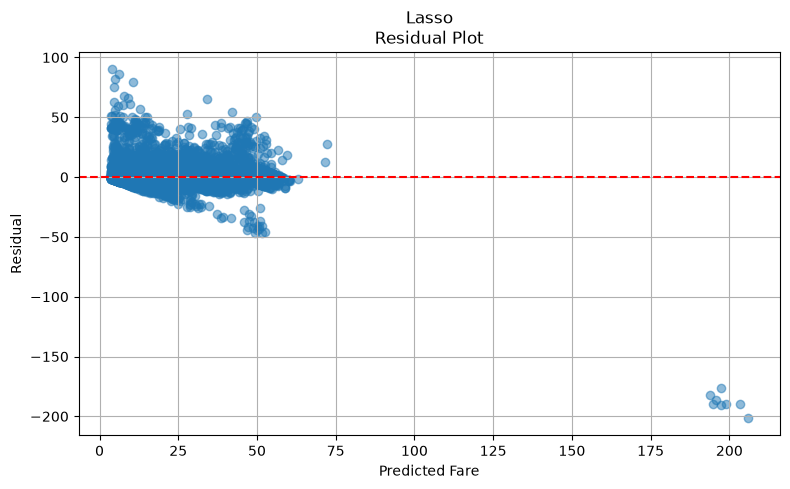

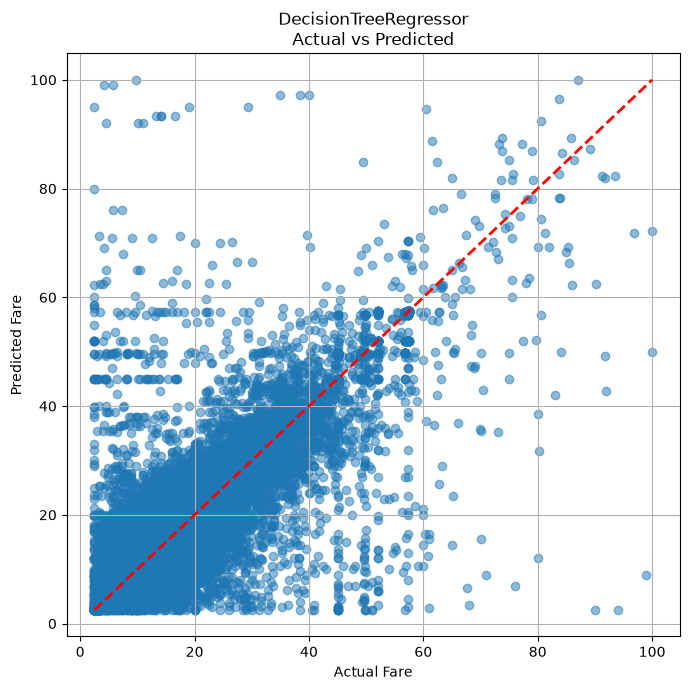

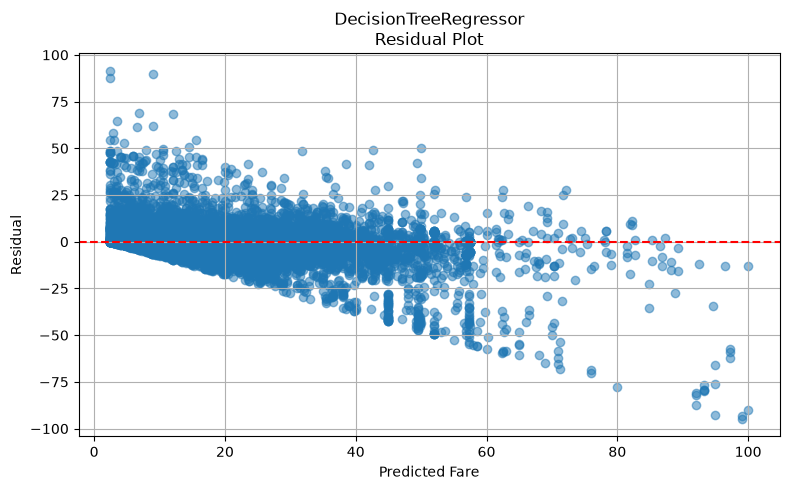

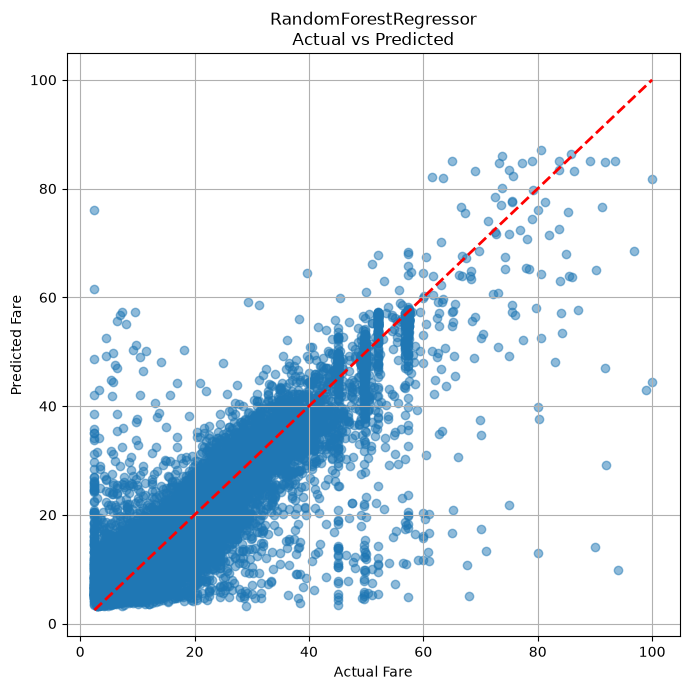

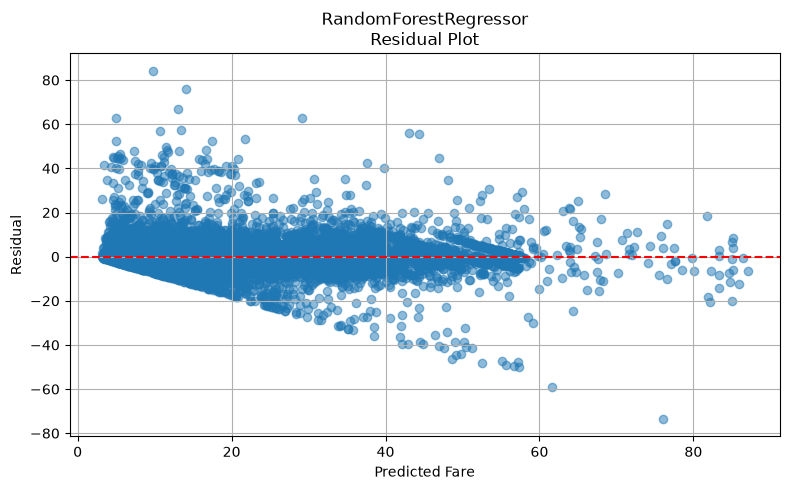

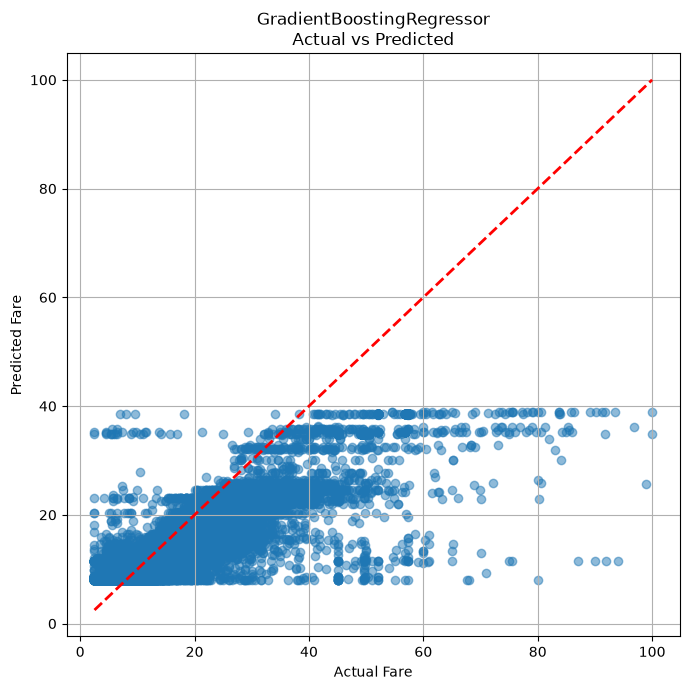

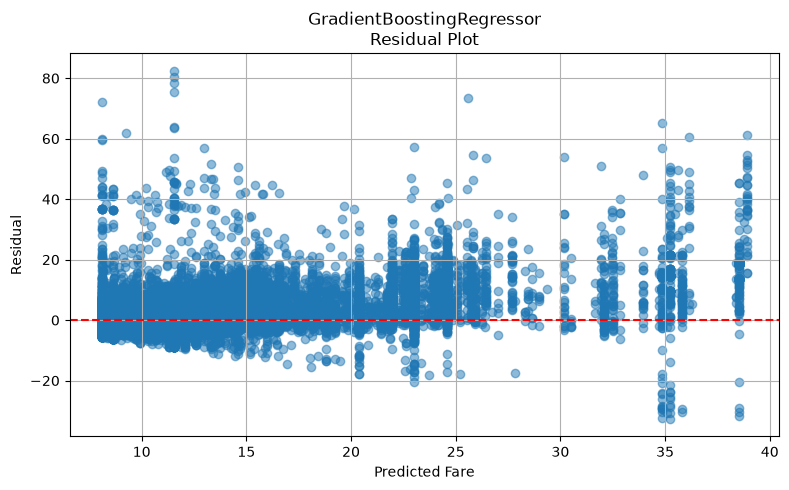

In [12]:
# Prediction & Residual plots for every model

for model_name, predictions in trainer.predictions.items():

    Visualizer.plot_predictions(
        y_test,
        predictions,
        model_name
    )

    Visualizer.plot_residuals(
        y_test,
        predictions,
        model_name
    )